In [1]:
print('Full Name: Sudheer Karanam')
print('Uplevel Email Address: sudkar.msc@gmail.com')
print('Name of the Problem Statement of Submission: MediWatch: likelihood of patient readmission')

Full Name: Sudheer Karanam
Uplevel Email Address: sudkar.msc@gmail.com
Name of the Problem Statement of Submission: MediWatch: likelihood of patient readmission


In [2]:
import os
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/My Drive/capstone/mediwatch')
dfRaw=pd.read_csv('diabetic_data_raw.csv')
dfRaw.info()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 

Observation:
1. The dataset contains columns with numeric and object datatypes, except for max_glu_serum and A1Cresult all other columns have full non-null values.

In [3]:
#Check for first few rows : any findings ?
dfRaw.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Observation:
1. Patient_nbr and encounter_id may be unique throughout and can be dropped.
2. Data is probable mix of numeric, boolean and object types
3. Weight data is not present (to be dropped)
4. Age columns needs encoding

In [4]:
#Check for structure - datatypes and number of not nulls
dfRaw.notnull().sum()

,0
encounter_id,101766
patient_nbr,101766
race,101766
gender,101766
age,101766
weight,101766
admission_type_id,101766
discharge_disposition_id,101766
admission_source_id,101766
time_in_hospital,101766


In [5]:
#Check for any duplicates
dfRaw.duplicated().sum()

np.int64(0)

Observation:
1. No duplicates found

In [6]:
dfRaw.shape

(101766, 50)

In [7]:
#Check the missing values across columns
dfRaw.isna().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


Observation:
1. max_glu_serum and A1Cresult has approx 90% data missing, lets get rid of them

In [8]:
dfRaw['gender'].value_counts() #

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


Observation:
1. gender has missing values for 3 rows, remove those records

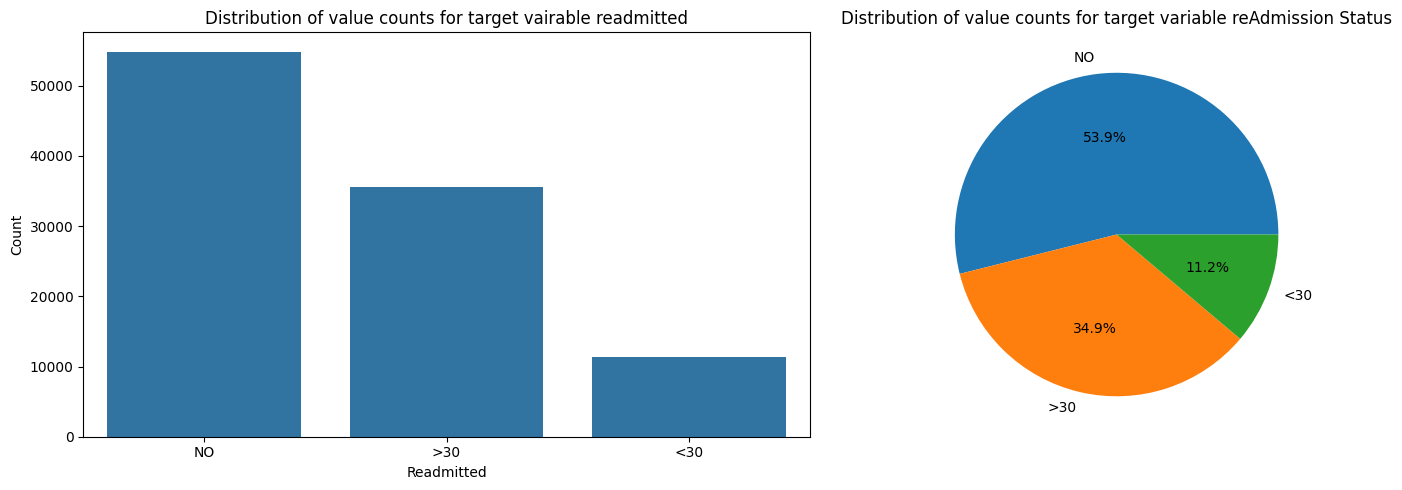

In [9]:
#Check for target variable's balance
ycounts=dfRaw['readmitted'].value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
sns.barplot(x=dfRaw['readmitted'].value_counts().index, y=dfRaw['readmitted'].value_counts().values, ax=axes[0])
axes[0].set_title('Distribution of value counts for target vairable readmitted')
axes[0].set_xlabel('Readmitted')
axes[0].set_ylabel('Count')

plt.pie(ycounts, labels=ycounts.index, autopct='%1.1f%%')
axes[1].set_title('Distribution of value counts for target variable reAdmission Status')

plt.tight_layout()
plt.show()

Observation:
1. Target is slightly tilted towards 'NO', may need SMOTE to balance data for Readmissions if <30days.
2. Predicting a readmission eligible person as NO (false negative) can have severe consequences.
3. Hence recall and a balanced f1_score will be important metrics.


**Data Pre-Processing**

In [10]:
#print(dfRaw['race'].value_counts()) # has few missing values, replace missing with majority value: Caucasian
#print(dfRaw['age'].value_counts())
#print(dfRaw['max_glu_serum'].value_counts()) #>90% of missing values, remove the column
#print(dfRaw['A1Cresult'].value_counts())  #>90% of missing values, remove the column
#print(dfRaw['weight'].value_counts())  #>90% of missing values, remove the column
#print(dfRaw['admission_type_id'].value_counts())
#print(dfRaw['discharge_disposition_id'].value_counts())
#print(dfRaw['admission_source_id'].value_counts())
#print(dfRaw['time_in_hospital'].value_counts())
#print(dfRaw['payer_code'].value_counts()) # has 50% missing data, lets remove it is more of admin info
#print(dfRaw['medical_specialty'].value_counts() # has 50% missing data, lets remove it is more of admin info
#print(dfRaw['examide'].value_counts()) # has only one value, not relevant, so remove the column
#print(dfRaw['citoglipton'].value_counts()) # has only one value, not relevant, so remove the column


In [11]:
#Data cleaning:
dfDataClean=dfRaw.copy()
dfDataClean.drop(['max_glu_serum', 'A1Cresult', 'weight','encounter_id','patient_nbr','payer_code','medical_specialty','examide','citoglipton'], axis=1, inplace=True)
dfDataClean=dfDataClean[dfDataClean['gender']!='Unknown/Invalid']
dfDataClean.loc[dfDataClean['race'] == "?", 'race'] = str('Caucasian')
#print(dfDataClean['race'].value_counts())


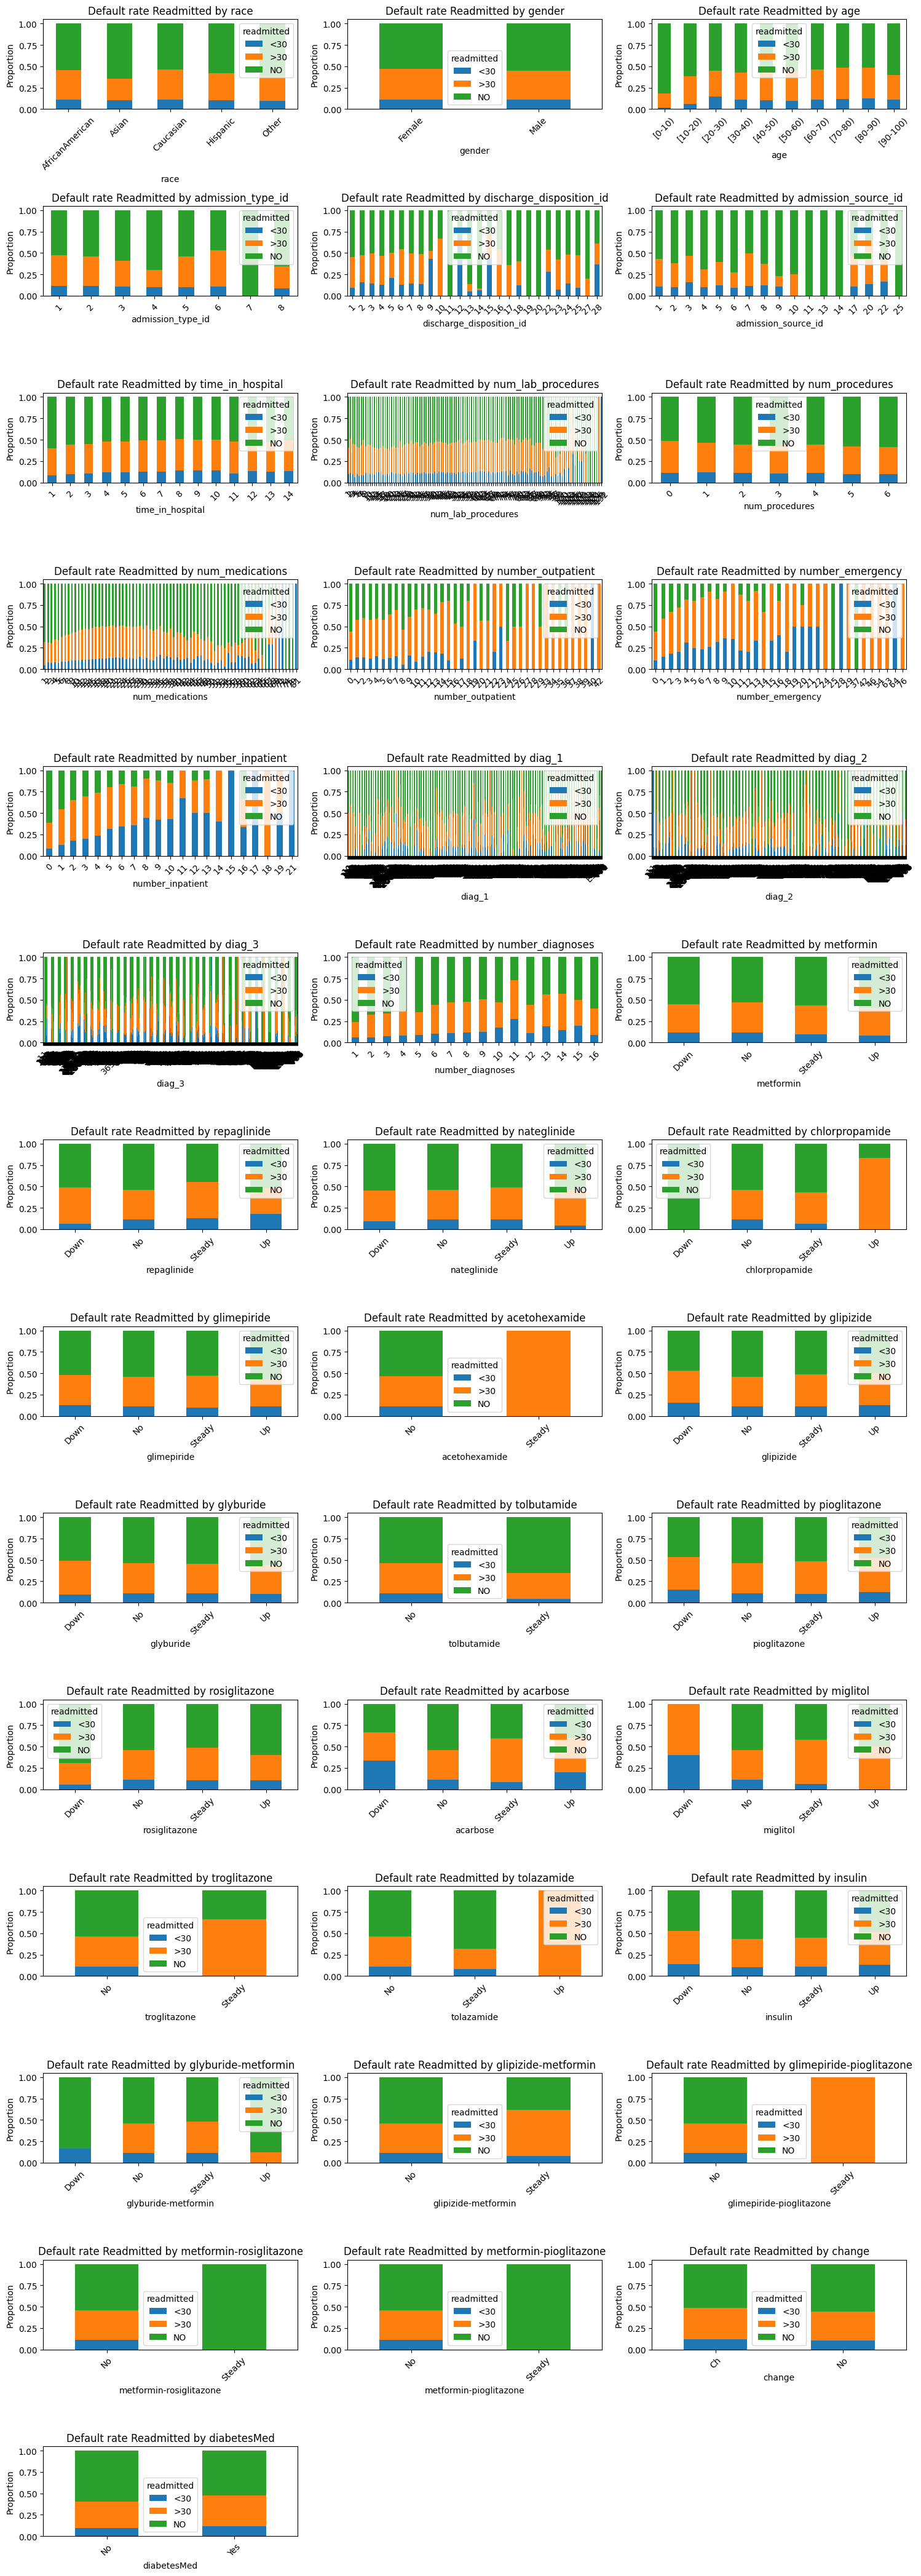

In [12]:
import math
#EDA
cols_for_eda = [col for col in dfDataClean.columns if col != 'readmitted']
#cols=['race','gender','age','admission_type_id','discharge_disposition_id','time_in_hospital','payer_code']

ncols = 3
nrows = math.ceil(len(cols_for_eda) / ncols)

fig,axes=plt.subplots(nrows=nrows, ncols=ncols, figsize=(15,nrows*3)) # Adjust figsize dynamically
axes=axes.flatten()

for i, col in enumerate(cols_for_eda): # Iterate over the filtered columns
  #print(col)
  normalizedCounts=dfDataClean.groupby(col)['readmitted'].value_counts(normalize=True).unstack()
  normalizedCounts.plot(kind='bar', stacked=True,ax=axes[i])
  axes[i].set_title(f"Default rate Readmitted by {col}")
  axes[i].set_ylabel("Proportion")
  axes[i].set_xlabel(col)
  axes[i].tick_params(axis='x',rotation=45)

# Hide any unused subplots
for j in range(len(cols_for_eda), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
#dfEDA=dfDataClean.copy()

In [13]:
objectCols = ['race', 'gender', 'age','diag_1','diag_2','diag_3','metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
print(objectCols)
  #Perform ohe for all category columns
map={}
for col in objectCols:
  dfDataClean[col]=dfDataClean[col].astype('category')
  code_to_label = dict(enumerate(dfDataClean[col].cat.categories))
  dfDataClean[col+'_encoded']=dfDataClean[col].cat.codes
  print(f"{col} --- {code_to_label}")
  map[col]=code_to_label
print(map)

['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
race --- {0: 'AfricanAmerican', 1: 'Asian', 2: 'Caucasian', 3: 'Hispanic', 4: 'Other'}
gender --- {0: 'Female', 1: 'Male'}
age --- {0: '[0-10)', 1: '[10-20)', 2: '[20-30)', 3: '[30-40)', 4: '[40-50)', 5: '[50-60)', 6: '[60-70)', 7: '[70-80)', 8: '[80-90)', 9: '[90-100)'}
diag_1 --- {0: '10', 1: '11', 2: '110', 3: '112', 4: '114', 5: '115', 6: '117', 7: '131', 8: '133', 9: '135', 10: '136', 11: '141', 12: '142', 13: '143', 14: '145', 15: '146', 16: '147', 17: '148', 18: '149', 19: '150', 20: '151', 21: '152', 22: '153', 23: '154', 24: '155', 25: '156', 26

###Perform encoding on target variable

---



In [14]:
dfDataClean['readmitted']=dfDataClean['readmitted'].astype('category')
code_to_label2 = dict(enumerate(dfDataClean['readmitted'].cat.categories))
print(code_to_label2)
dfDataClean['readmitted']=dfDataClean['readmitted'].cat.codes
dfDataClean['readmitted'].value_counts()

{0: '<30', 1: '>30', 2: 'NO'}


,count
readmitted,
2,54861
1,35545
0,11357


#Observation:

Data is imbalanced for <30days readmission, may need some SMOTE.

In [15]:
#Perform label encoding for target column
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# dfDataClean['readmitted']=dfDataClean['readmitted'].astype('category')
# dfDataClean['readmitted']=dfDataClean['readmitted'].cat.codes
# #dfDataClean['readmitted']=le.fit_transform(dfDataClean['readmitted'])
# #dfDataClean['race'].value_counts()


<Axes: >

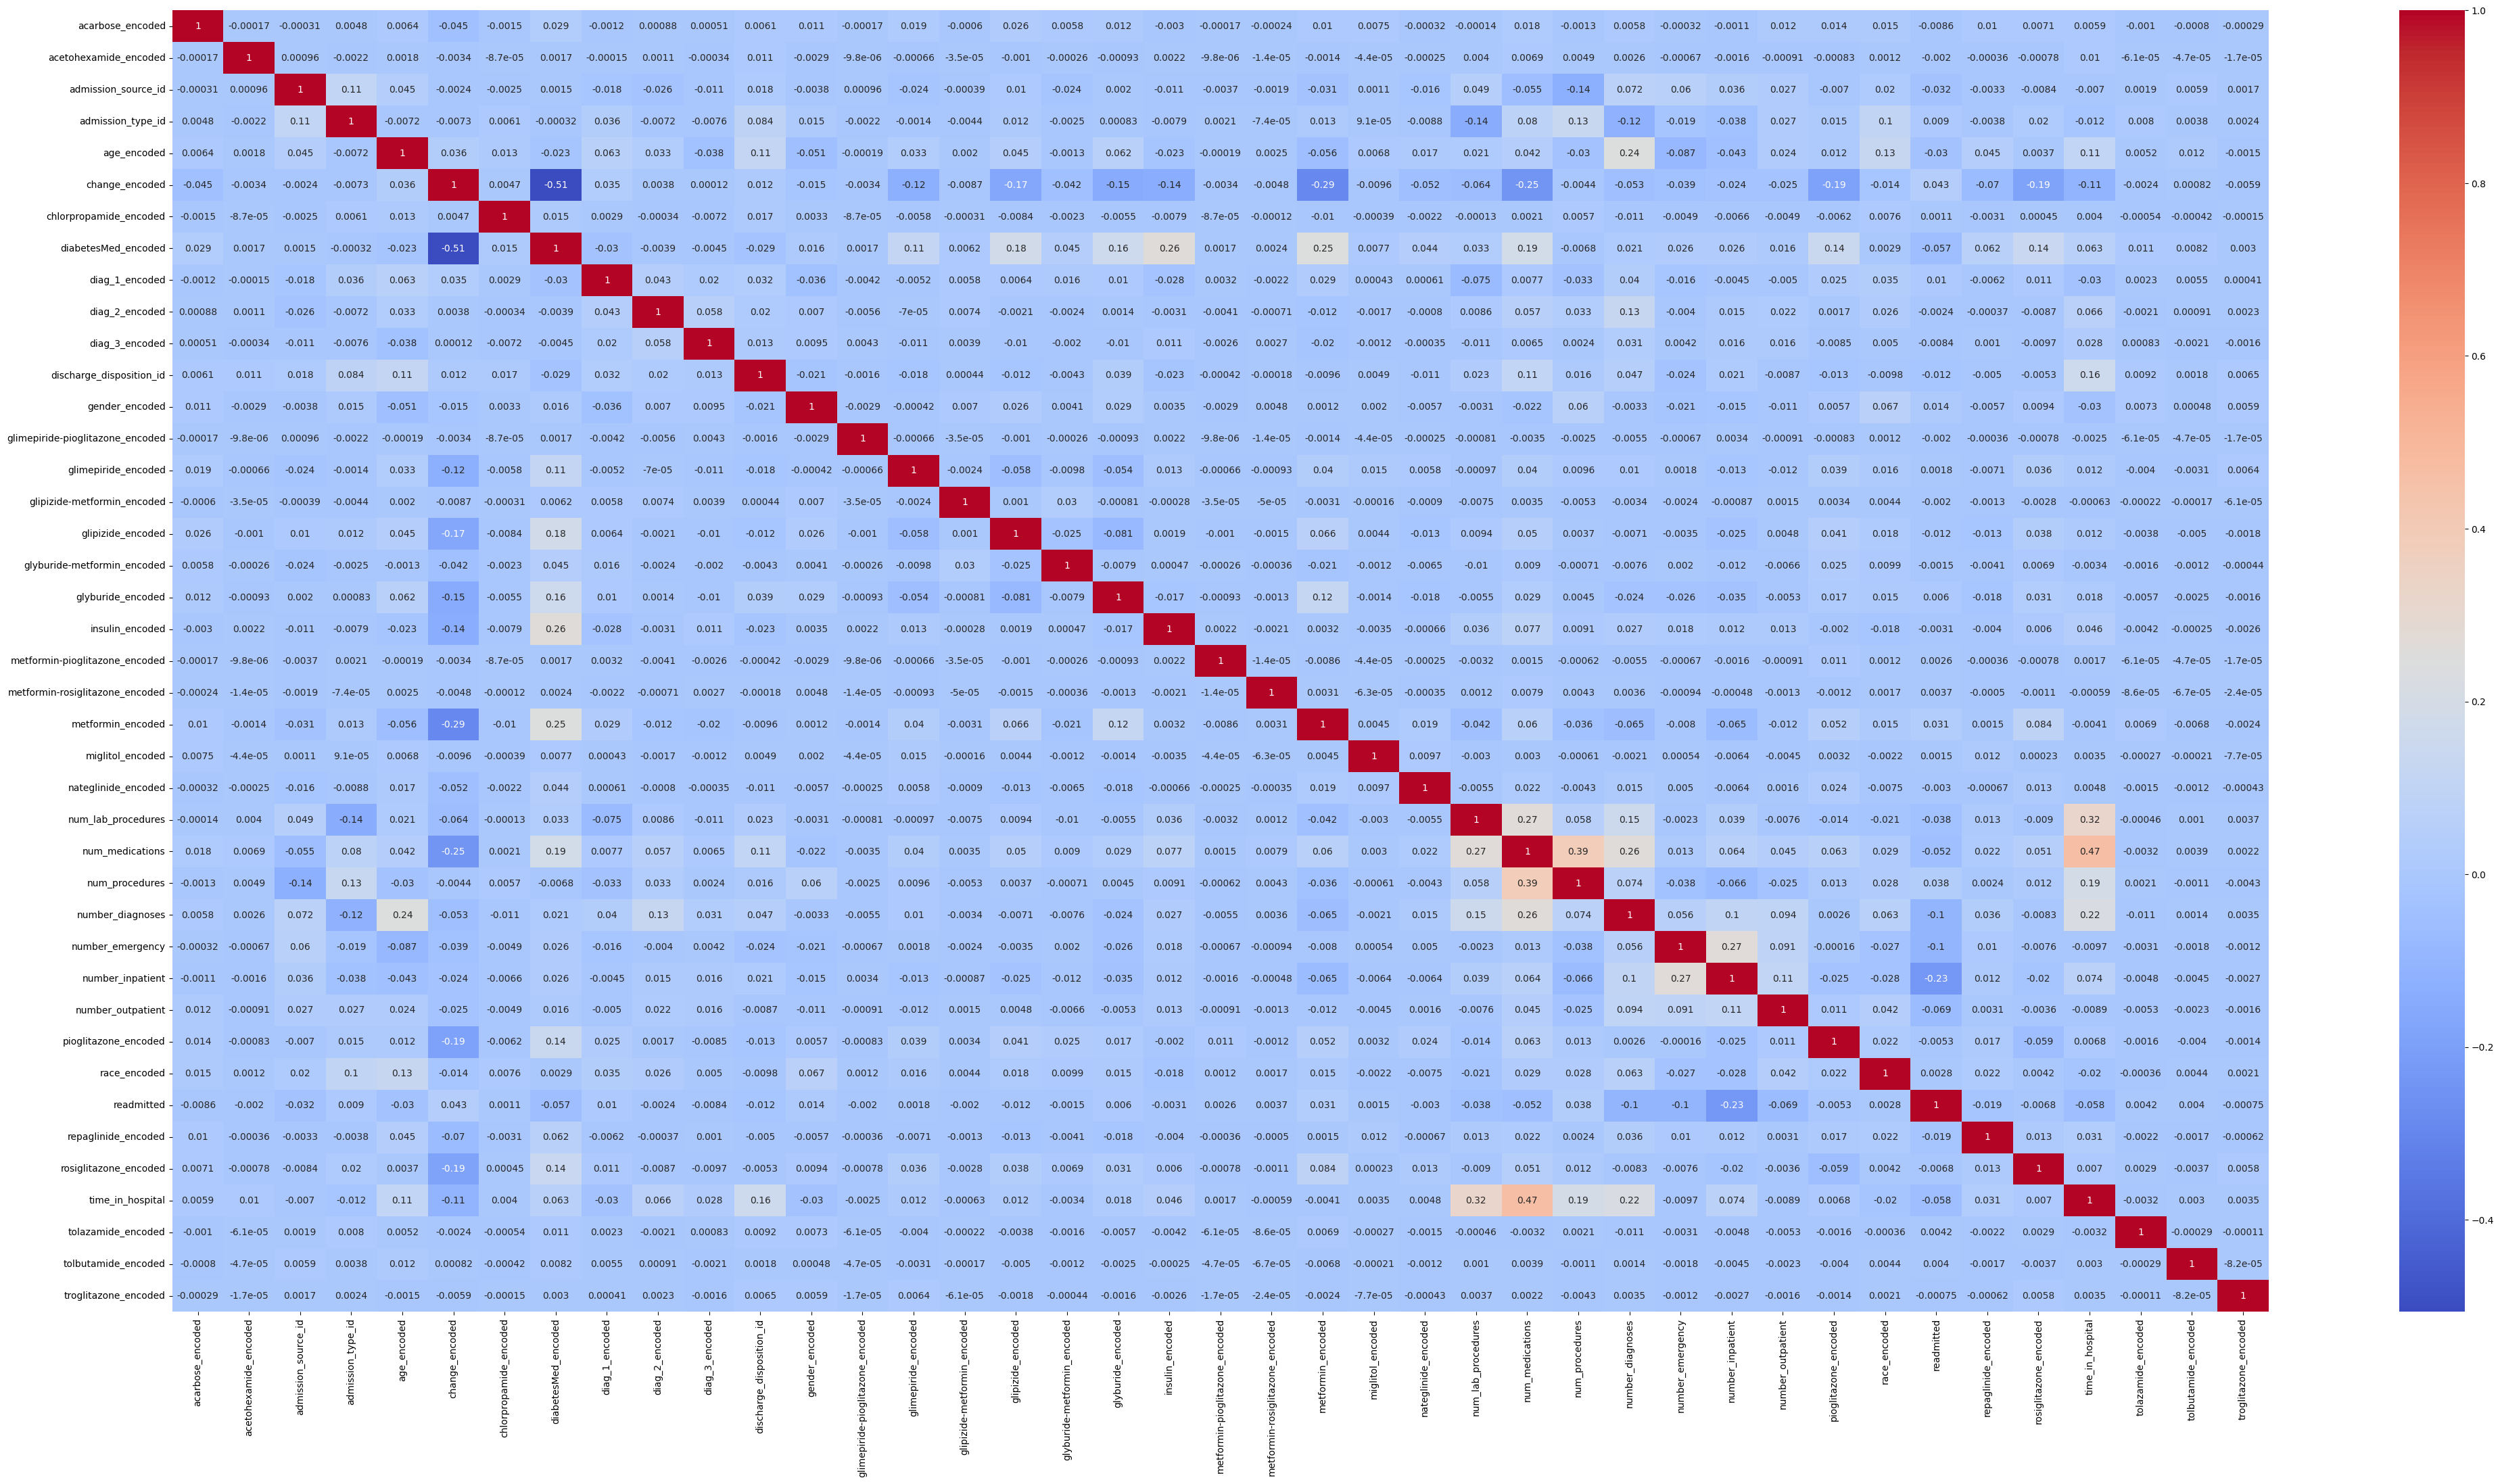

In [16]:
dfDataCleanCorr=dfDataClean.copy()
dfDataCleanCorr.drop(objectCols, axis=1, inplace=True)
dfDataCleanCorr=dfDataCleanCorr.sort_index(axis=1)
plt.figure(figsize=(50,25))
sns.heatmap(dfDataCleanCorr.corr(), annot=True, cmap='coolwarm')

Observation:
1. Heatmap does not show any strong co-relation between columns


In [18]:
dfDataCleanCorr.info()
dfDataCleanCorr.columns

<class 'pandas.core.frame.DataFrame'>
Index: 101763 entries, 0 to 101765
Data columns (total 41 columns):
 #   Column                            Non-Null Count   Dtype
---  ------                            --------------   -----
 0   acarbose_encoded                  101763 non-null  int8 
 1   acetohexamide_encoded             101763 non-null  int8 
 2   admission_source_id               101763 non-null  int64
 3   admission_type_id                 101763 non-null  int64
 4   age_encoded                       101763 non-null  int8 
 5   change_encoded                    101763 non-null  int8 
 6   chlorpropamide_encoded            101763 non-null  int8 
 7   diabetesMed_encoded               101763 non-null  int8 
 8   diag_1_encoded                    101763 non-null  int16
 9   diag_2_encoded                    101763 non-null  int16
 10  diag_3_encoded                    101763 non-null  int16
 11  discharge_disposition_id          101763 non-null  int64
 12  gender_encoded       

Index(['acarbose_encoded', 'acetohexamide_encoded', 'admission_source_id',
       'admission_type_id', 'age_encoded', 'change_encoded',
       'chlorpropamide_encoded', 'diabetesMed_encoded', 'diag_1_encoded',
       'diag_2_encoded', 'diag_3_encoded', 'discharge_disposition_id',
       'gender_encoded', 'glimepiride-pioglitazone_encoded',
       'glimepiride_encoded', 'glipizide-metformin_encoded',
       'glipizide_encoded', 'glyburide-metformin_encoded', 'glyburide_encoded',
       'insulin_encoded', 'metformin-pioglitazone_encoded',
       'metformin-rosiglitazone_encoded', 'metformin_encoded',
       'miglitol_encoded', 'nateglinide_encoded', 'num_lab_procedures',
       'num_medications', 'num_procedures', 'number_diagnoses',
       'number_emergency', 'number_inpatient', 'number_outpatient',
       'pioglitazone_encoded', 'race_encoded', 'readmitted',
       'repaglinide_encoded', 'rosiglitazone_encoded', 'time_in_hospital',
       'tolazamide_encoded', 'tolbutamide_encoded', 't

###Univariate analysis

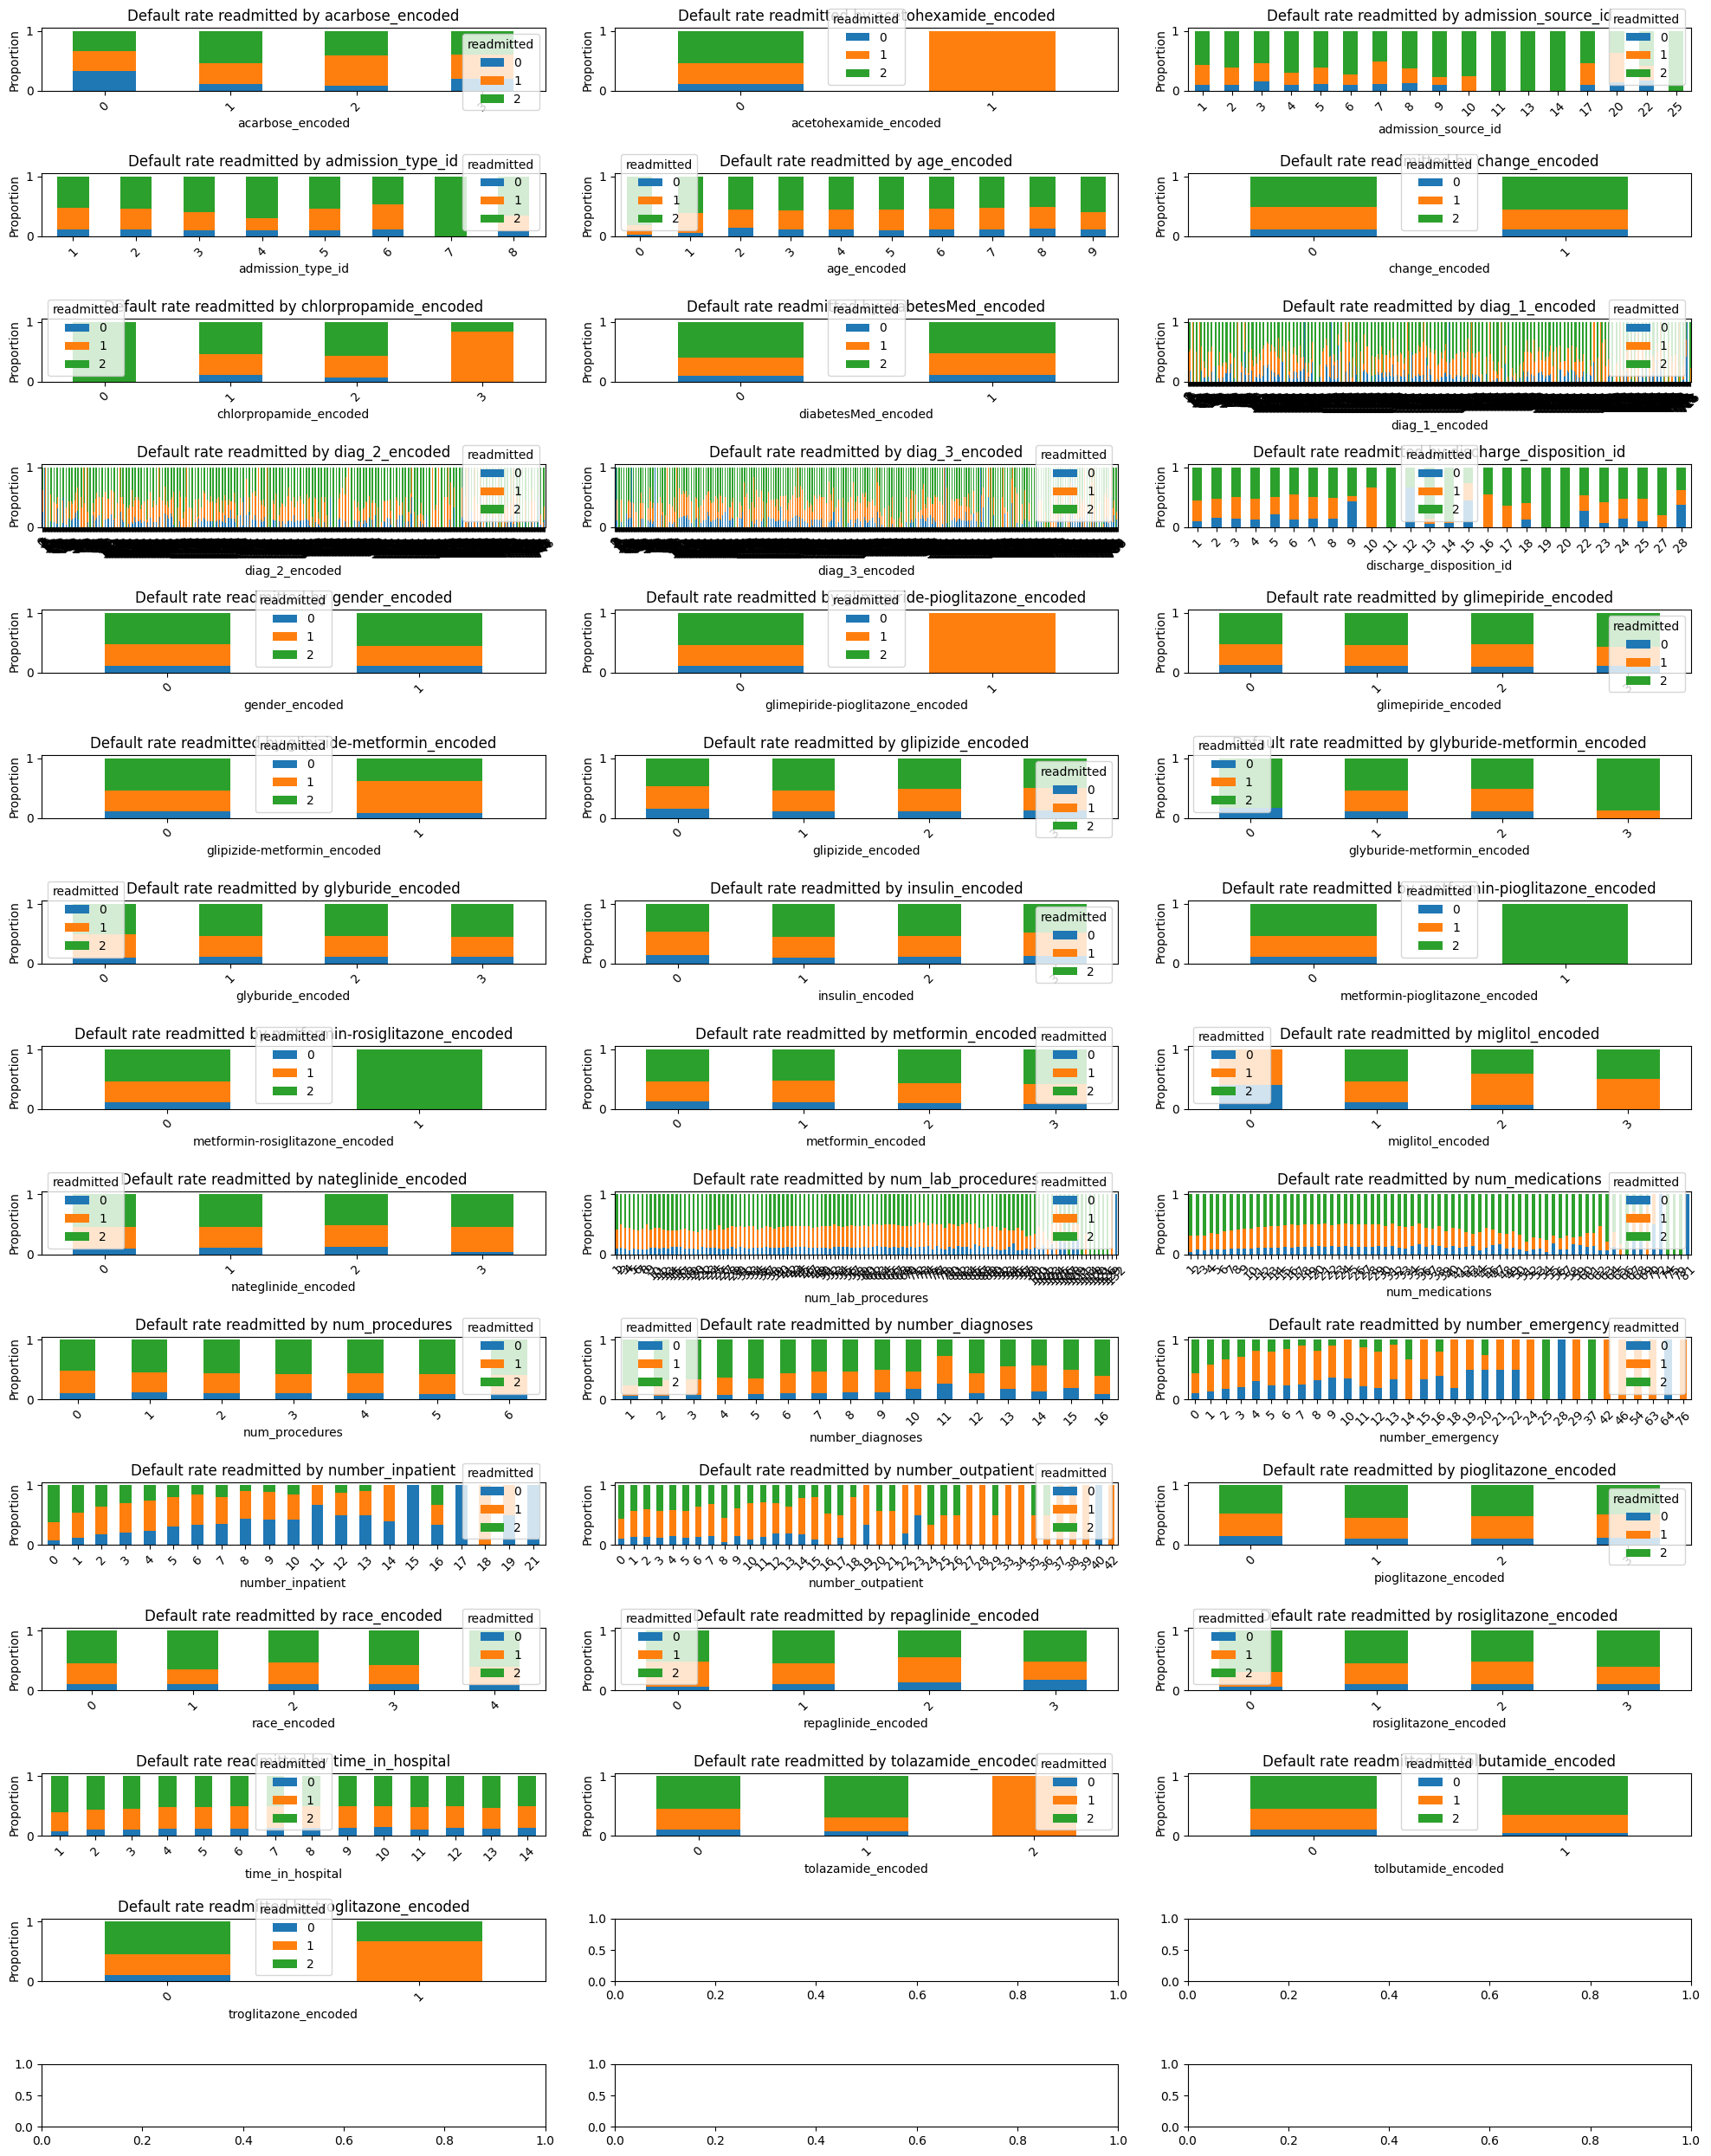

In [24]:
cols=['acarbose_encoded', 'acetohexamide_encoded', 'admission_source_id',
       'admission_type_id', 'age_encoded', 'change_encoded',
       'chlorpropamide_encoded', 'diabetesMed_encoded', 'diag_1_encoded',
       'diag_2_encoded', 'diag_3_encoded', 'discharge_disposition_id',
       'gender_encoded', 'glimepiride-pioglitazone_encoded',
       'glimepiride_encoded', 'glipizide-metformin_encoded',
       'glipizide_encoded', 'glyburide-metformin_encoded', 'glyburide_encoded',
       'insulin_encoded', 'metformin-pioglitazone_encoded',
       'metformin-rosiglitazone_encoded', 'metformin_encoded',
       'miglitol_encoded', 'nateglinide_encoded', 'num_lab_procedures',
       'num_medications', 'num_procedures', 'number_diagnoses',
       'number_emergency', 'number_inpatient', 'number_outpatient',
       'pioglitazone_encoded', 'race_encoded',
       'repaglinide_encoded', 'rosiglitazone_encoded', 'time_in_hospital',
       'tolazamide_encoded', 'tolbutamide_encoded', 'troglitazone_encoded']
fig, axes=plt.subplots(nrows=15, ncols=3,figsize=(20,25))
axes=axes.flatten()

for i, col in enumerate(cols):
#i=0
#col='term'
  normalizedCounts=dfDataCleanCorr.groupby(col)['readmitted'].value_counts(normalize=True).unstack()
  normalizedCounts.plot(kind='bar', stacked=True,ax=axes[i])
  axes[i].set_title(f"Default rate readmitted by {col}")
  axes[i].set_ylabel("Proportion")
  axes[i].set_xlabel(col)
  axes[i].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

###Observation:
 Data outcomes looks evenly distributed and no skewness observed.


In [25]:
# Now lets run data against models

from sklearn.model_selection import train_test_split
dfDataForModel=dfDataCleanCorr.copy()
y = dfDataForModel['readmitted']
X = dfDataForModel.drop('readmitted', axis=1)
xtrain,xtest,ytrain, ytest=train_test_split(X,y, test_size=0.2, random_state=42)

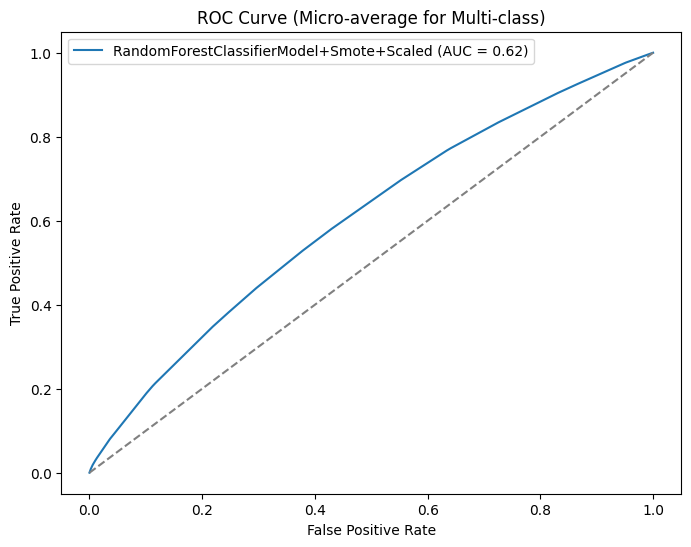

RandomForestClassifierModel+Smote+Scaled:
Precision: 0.51
Recall: 0.54
F1-Score: 0.52
Accuracy: 0.54
ROC AUC: 0.62
Classification report:
              precision    recall  f1-score   support

           0       0.23      0.07      0.10      2269
           1       0.43      0.43      0.43      7068
           2       0.61      0.71      0.66     11016

    accuracy                           0.54     20353
   macro avg       0.43      0.40      0.40     20353
weighted avg       0.51      0.54      0.52     20353



In [27]:
##Check model performance on RandomForestClassifier regression

#Build a random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score,classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

rfModel=RandomForestClassifier(n_estimators=10, random_state=42, class_weight='balanced')
rfModel.fit(xtrain,ytrain)
ypred=rfModel.predict(xtest)

precision=precision_score(ytest,ypred, average='weighted') # Added average parameter for multi-class classification
recall=recall_score(ytest,ypred, average='weighted') # Added average parameter for multi-class classification
f1=f1_score(ytest,ypred, average='weighted') # Added average parameter for multi-class classification
accuracy=accuracy_score(ytest,ypred)
cr=classification_report(ytest,ypred)


#Calculate ROC
# For multi-class classification, roc_auc_score requires either `multi_class` or one-vs-rest (ovr) strategy
# and `average` parameter. Let's adjust for this.
# First, get probabilities for each class
yproba = rfModel.predict_proba(xtest)
# For ROC AUC, we can either compute for each class (ovr) or macro/weighted average.
# Let's compute for the positive class (assuming it's class 1 from your encoding {0: '<30', 1: '>30', 2: 'NO'})
# However, typically AUC is calculated for binary or one-vs-rest for multiclass.
# Given 'readmitted' has 3 classes, let's use 'ovo' or 'ovr' multi_class option.
# For plotting a single ROC curve for multi-class, it's common to use one-vs-rest (ovr) and average.
roc_auc = roc_auc_score(ytest, yproba, multi_class='ovr', average='weighted')
# For ROC curve plotting, typically it's for binary classification. For multi-class, you might plot one-vs-rest.
# Let's plot for class 0 (readmitted <30) vs all others as an example.
# Note: This will not generate 3 ROC curves, but one for a specific class.
# To plot a single ROC curve for the entire multi-class problem is complex and often done by micro/macro averaging.
# For simplicity, let's plot the ROC curve for class 0 (readmitted <30) versus other classes.
# This requires converting ytest to binary for this specific class.
# fpr, tpr, thresholds = roc_curve(ytest == 0, yproba[:, 0]) # Example for class 0

# If you want to plot a single aggregated ROC curve, you need to binarize the output
from sklearn.preprocessing import LabelBinarizer

# Binarize the true labels
lb = LabelBinarizer()
ytest_binarized = lb.fit_transform(ytest)

# If ytest has 3 classes, ytest_binarized will have 3 columns
# roc_curve expects binary labels, so for a single plot, we typically aggregate
# One approach for multi-class ROC curve is to use micro or macro averaging
# For plotting, let's plot one-vs-rest for each class or an aggregated version.
# Given the previous plots were single, let's try an aggregated micro-average ROC curve

# Compute micro-average ROC curve and ROC area
fpr = dict()
tpr = dict()
thresholds = dict()
n_classes = len(lb.classes_)

for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(ytest_binarized[:, i], yproba[:, i])

# Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average it and compute AUC
mean_tpr /= n_classes

fpr["micro"] = all_fpr
tpr["micro"] = mean_tpr

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"], label=f"RandomForestClassifierModel+Smote+Scaled (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Micro-average for Multi-class)')
plt.legend(loc="best")
plt.show()

print(f'RandomForestClassifierModel+Smote+Scaled:\nPrecision: {precision:.2f}\nRecall: {recall:.2f}\nF1-Score: {f1:.2f}\nAccuracy: {accuracy:.2f}\nROC AUC: {roc_auc:.2f}')
print('Classification report:')
print(cr)


###Observation:
 RandomForestClassifier Model is not good in predicting readmissions if <30 days.


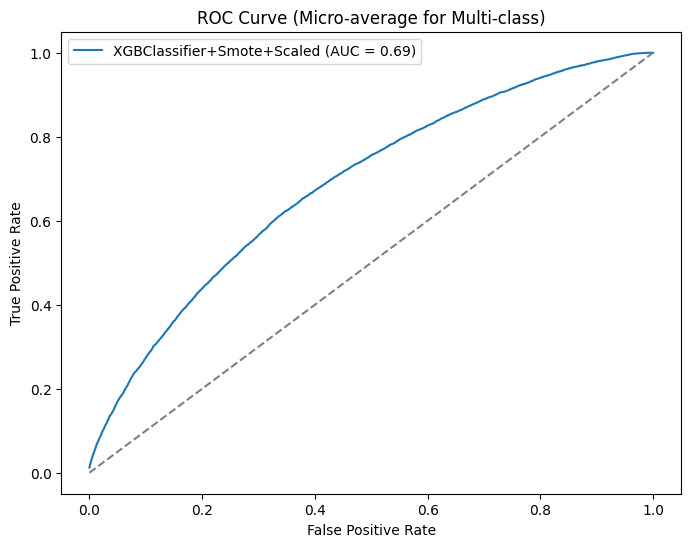

XGBClassifier+Smote+Scaled:
Precision: 0.57
Recall: 0.60
F1-Score: 0.56
Accuracy: 0.60
ROC AUC: 0.69
Classfication report:
              precision    recall  f1-score   support

           0       0.44      0.05      0.09      2269
           1       0.51      0.41      0.46      7068
           2       0.63      0.83      0.72     11016

    accuracy                           0.60     20353
   macro avg       0.53      0.43      0.42     20353
weighted avg       0.57      0.60      0.56     20353



In [30]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score,classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
import numpy as np # Import numpy

xgbModel=xgb.XGBClassifier(n_estimators=100, random_state=42)
xgbModel.fit(xtrain,ytrain)

# Predict on the test set
ypred = xgbModel.predict(xtest)

precision=precision_score(ytest,ypred, average='weighted') # Added average parameter for multi-class classification
recall=recall_score(ytest,ypred, average='weighted') # Added average parameter for multi-class classification
f1=f1_score(ytest,ypred, average='weighted') # Added average parameter for multi-class classification
accuracy=accuracy_score(ytest,ypred)
cr=classification_report(ytest,ypred)

#Calculate ROC
# First, get probabilities for each class
yproba = xgbModel.predict_proba(xtest)
# For ROC AUC in multi-class, specify multi_class and average parameters
roc_auc = roc_auc_score(ytest, yproba, multi_class='ovr', average='weighted')

# If you want to plot a single aggregated ROC curve, you need to binarize the output

# Binarize the true labels
lb = LabelBinarizer()
ytest_binarized = lb.fit_transform(ytest)

# Compute micro-average ROC curve and ROC area
fpr = dict()
tpr = dict()
thresholds = dict()
n_classes = len(lb.classes_)

for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(ytest_binarized[:, i], yproba[:, i])

# Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average it and compute AUC
mean_tpr /= n_classes

fpr["micro"] = all_fpr
tpr["micro"] = mean_tpr

#Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"], label=f"XGBClassifier+Smote+Scaled (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Micro-average for Multi-class)')
plt.legend(loc="best")
plt.show()

print(f'XGBClassifier+Smote+Scaled:\nPrecision: {precision:.2f}\nRecall: {recall:.2f}\nF1-Score: {f1:.2f}\nAccuracy: {accuracy:.2f}\nROC AUC: {roc_auc:.2f}')
print('Classfication report:')
print(cr)

###Observation:
 Overall, the XGBoost model shows slightly better performance compared to the Random Forest model, especially in terms of overall accuracy and ROC AUC. However, similar to the previous model, it still has significant difficulty accurately predicting readmissions for the '<30' class. The micro-average ROC curve visually represents the overall trade-off between true positive rate and false positive rate, with an AUC of 0.69.



In [31]:
#Impute with simpleImputer and Smote to fix class imbalance
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

imputer=SimpleImputer(strategy='mean')
xtrainImputed=imputer.fit_transform(X)

smote=SMOTE(random_state=42)
xtrainSmote, ytrainSmote=smote.fit_resample(xtrainImputed,y)
ytrainSmote.value_counts()

,count
readmitted,
2,54861
1,54861
0,54861


In [32]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
minMaxScaler=MinMaxScaler()
xtrainScaled=minMaxScaler.fit_transform(xtrainSmote)
xtestScaled=minMaxScaler.transform(xtest)
xtrainScaled.shape, xtestScaled.shape

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


((164583, 40), (20353, 40))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


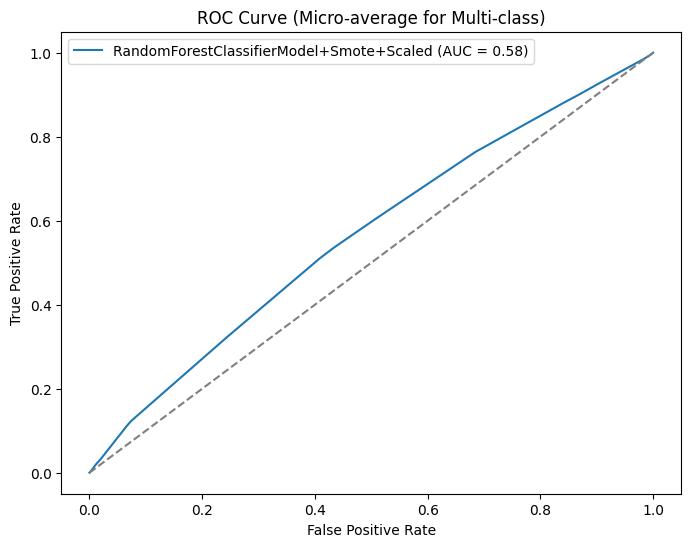

RandomForestClassifierModel+Smote+Scaled:
Precision: 0.99
Recall: 0.99
F1-Score: 0.99
Accuracy: 0.99
ROC AUC: 0.58
Classification report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2269
           1       0.99      0.99      0.99      7068
           2       0.99      0.99      0.99     11016

    accuracy                           0.99     20353
   macro avg       0.99      0.99      0.99     20353
weighted avg       0.99      0.99      0.99     20353



In [33]:
##Re RUN RandomForestClassifier on SMOTE+SCALED DATA

#Build a random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score,classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

rfModel=RandomForestClassifier(n_estimators=10, random_state=42, class_weight='balanced')
rfModel.fit(xtrainScaled,ytrainSmote)
ypred=rfModel.predict(xtestScaled)

precision=precision_score(ytest,ypred, average='weighted') # Added average parameter for multi-class classification
recall=recall_score(ytest,ypred, average='weighted') # Added average parameter for multi-class classification
f1=f1_score(ytest,ypred, average='weighted') # Added average parameter for multi-class classification
accuracy=accuracy_score(ytest,ypred)
cr=classification_report(ytest,ypred)


#Calculate ROC
# For multi-class classification, roc_auc_score requires either `multi_class` or one-vs-rest (ovr) strategy
# and `average` parameter. Let's adjust for this.
# First, get probabilities for each class
yproba = rfModel.predict_proba(xtest)
# For ROC AUC, we can either compute for each class (ovr) or macro/weighted average.
# Let's compute for the positive class (assuming it's class 1 from your encoding {0: '<30', 1: '>30', 2: 'NO'})
# However, typically AUC is calculated for binary or one-vs-rest for multiclass.
# Given 'readmitted' has 3 classes, let's use 'ovo' or 'ovr' multi_class option.
# For plotting a single ROC curve for multi-class, it's common to use one-vs-rest (ovr) and average.
roc_auc = roc_auc_score(ytest, yproba, multi_class='ovr', average='weighted')
# For ROC curve plotting, typically it's for binary classification. For multi-class, you might plot one-vs-rest.
# Let's plot for class 0 (readmitted <30) vs all others as an example.
# Note: This will not generate 3 ROC curves, but one for a specific class.
# To plot a single ROC curve for the entire multi-class problem is complex and often done by micro/macro averaging.
# For simplicity, let's plot the ROC curve for class 0 (readmitted <30) versus other classes.
# This requires converting ytest to binary for this specific class.
# fpr, tpr, thresholds = roc_curve(ytest == 0, yproba[:, 0]) # Example for class 0

# If you want to plot a single aggregated ROC curve, you need to binarize the output
from sklearn.preprocessing import LabelBinarizer

# Binarize the true labels
lb = LabelBinarizer()
ytest_binarized = lb.fit_transform(ytest)

# If ytest has 3 classes, ytest_binarized will have 3 columns
# roc_curve expects binary labels, so for a single plot, we typically aggregate
# One approach for multi-class ROC curve is to use micro or macro averaging
# For plotting, let's plot one-vs-rest for each class or an aggregated version.
# Given the previous plots were single, let's try an aggregated micro-average ROC curve

# Compute micro-average ROC curve and ROC area
fpr = dict()
tpr = dict()
thresholds = dict()
n_classes = len(lb.classes_)

for i in range(n_classes):
    fpr[i], tpr[i], thresholds[i] = roc_curve(ytest_binarized[:, i], yproba[:, i])

# Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average it and compute AUC
mean_tpr /= n_classes

fpr["micro"] = all_fpr
tpr["micro"] = mean_tpr

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"], label=f"RandomForestClassifierModel+Smote+Scaled (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Micro-average for Multi-class)')
plt.legend(loc="best")
plt.show()

print(f'RandomForestClassifierModel+Smote+Scaled:\nPrecision: {precision:.2f}\nRecall: {recall:.2f}\nF1-Score: {f1:.2f}\nAccuracy: {accuracy:.2f}\nROC AUC: {roc_auc:.2f}')
print('Classification report:')
print(cr)

###Observation: RandomForestClassifier gives a better score on SMOTE + SCALED data.